<a href="https://colab.research.google.com/github/yabahddoulailaencg-a11y/BD-DS-2026/blob/main/chomage_maroc_data_science.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
import numpy as np
import pandas as pd

# ===== 1. Dataset principal 1999-2025 =====
annees = list(range(1999, 2026))

# Chômage national (%) : HCP (via Banque mondiale) 1999-2016 ; notes annuelles HCP 2017-2025
chom = {1999:13.939,2000:np.nan,2001:12.464,2002:11.588,2003:11.916,2004:10.827,2005:11.009,2006:9.668,
        2007:9.56,2008:9.566,2009:8.96,2010:9.09,2011:8.912,2012:8.99,2013:9.233,2014:9.7,2015:9.46,2016:9.3,
        2017:10.2,2018:9.5,2019:9.2,2020:11.9,2021:12.3,2022:11.8,2023:13.0,2024:13.3,2025:13.0}

# Croissance du PIB réel (%) : FMI
pib = {1999:1.1,2000:1.9,2001:7.3,2002:3.1,2003:6.0,2004:4.8,2005:3.3,2006:7.6,2007:3.5,2008:5.9,2009:4.2,
       2010:3.8,2011:5.2,2012:3.0,2013:4.5,2014:2.7,2015:4.3,2016:0.5,2017:5.1,2018:3.1,2019:2.9,2020:-7.2,
       2021:7.9,2022:0.8,2023:3.4,2024:3.2,2025:4.4}

# Inflation (%) : FMI
infl = {1999:0.7,2000:1.9,2001:0.6,2002:2.8,2003:1.2,2004:1.5,2005:1.0,2006:3.3,2007:2.0,2008:3.9,2009:2.2,
        2010:0.9,2011:0.8,2012:0.8,2013:1.6,2014:0.4,2015:1.4,2016:1.5,2017:0.7,2018:1.6,2019:0.2,2020:0.6,
        2021:1.4,2022:6.2,2023:6.1,2024:1.0,2025:1.0}

# Emploi agricole (% de l'emploi total) : estimation OIT (Banque mondiale)
agri = {1999:45.64,2000:45.43,2001:44.84,2002:44.38,2003:43.90,2004:45.83,2005:45.48,2006:43.40,2007:42.74,
        2008:41.98,2009:41.30,2010:40.57,2011:39.78,2012:39.22,2013:38.40,2014:37.57,2015:36.69,2016:35.96,
        2017:35.03,2018:34.15,2019:33.25,2023:29.59}

df = pd.DataFrame({"annee": annees})
df["chomage"] = df.annee.map(chom)
df["croissance_pib"] = df.annee.map(pib)
df["inflation"] = df.annee.map(infl)
df["emploi_agricole"] = df.annee.map(agri)
df.to_csv("chomage_maroc_brut.csv", index=False)

# ===== 2. Détail HCP 2017-2025 =====
hcp = pd.DataFrame({
    "annee":    [2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025],
    "national": [10.2, 9.5, 9.2, 11.9, 12.3, 11.8, 13.0, 13.3, 13.0],
    "urbain":   [14.7, 13.8, 12.9, 15.8, 16.9, 15.8, 16.8, 16.9, 16.4],
    "rural":    [4.0, 3.6, 3.7, 5.9, 5.0, 5.2, 6.3, 6.8, 6.6],
    "jeunes_15_24": [np.nan, np.nan, 24.9, 31.2, 31.8, 32.7, 35.8, 36.7, 37.2],
    "femmes":       [np.nan, np.nan, 13.5, 16.2, 16.8, 17.2, 18.3, 19.4, 20.5],
    "diplomes":     [np.nan, np.nan, 15.7, 18.5, 19.6, 18.6, 19.7, 19.6, 19.1],
    # Emplois créés (+) ou perdus (-) sur un an, en milliers
    "emplois_agriculture_milliers": [np.nan, np.nan, np.nan, -273, 68, -215, -202, -137, -41],
    "emplois_services_milliers":    [np.nan, np.nan, np.nan, -107, 115, 164, 15, 160, 123],
    "emplois_industrie_milliers":   [np.nan, np.nan, np.nan, -37, -19, 28, 7, 46, 46],
    "emplois_btp_milliers":         [np.nan, np.nan, np.nan, -9, 71, -1, 19, 13, 64],
})
hcp.to_csv("hcp_detail_2017_2025.csv", index=False)

# ===== 3. Chômage strict par groupe, T2 2026 (nouvelle enquête EMO du HCP) =====
emo = pd.DataFrame({
    "groupe": ["Rural", "Hommes", "Ensemble", "Diplôme de base", "Urbain", "25-34 ans",
               "Femmes", "Diplôme intermédiaire", "Diplôme avancé", "Jeunes 15-24 ans"],
    "taux":   [5.4, 8.1, 9.5, 11.4, 11.9, 14.5, 14.8, 16.0, 16.7, 27.2],
})
emo.to_csv("emo_2026_T2.csv", index=False)

# ===== Affichage =====
display(df)
display(hcp)
display(emo)

,annee,chomage,croissance_pib,inflation,emploi_agricole
0,1999,13.939,1.1,0.7,45.64
1,2000,NaN,1.9,1.9,45.43
2,2001,12.464,7.3,0.6,44.84
3,2002,11.588,3.1,2.8,44.38
4,2003,11.916,6.0,1.2,43.90
5,2004,10.827,4.8,1.5,45.83
6,2005,11.009,3.3,1.0,45.48
7,2006,9.668,7.6,3.3,43.40
8,2007,9.560,3.5,2.0,42.74
9,2008,9.566,5.9,3.9,41.98


,annee,national,urbain,rural,jeunes_15_24,femmes,diplomes,emplois_agriculture_milliers,emplois_services_milliers,emplois_industrie_milliers,emplois_btp_milliers
0,2017,10.2,14.7,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2018,9.5,13.8,3.6,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2019,9.2,12.9,3.7,24.9,13.5,15.7,NaN,NaN,NaN,NaN
3,2020,11.9,15.8,5.9,31.2,16.2,18.5,-273.0,-107.0,-37.0,-9.0
4,2021,12.3,16.9,5.0,31.8,16.8,19.6,68.0,115.0,-19.0,71.0
5,2022,11.8,15.8,5.2,32.7,17.2,18.6,-215.0,164.0,28.0,-1.0
6,2023,13.0,16.8,6.3,35.8,18.3,19.7,-202.0,15.0,7.0,19.0
7,2024,13.3,16.9,6.8,36.7,19.4,19.6,-137.0,160.0,46.0,13.0
8,2025,13.0,16.4,6.6,37.2,20.5,19.1,-41.0,123.0,46.0,64.0


,groupe,taux
0,Rural,5.4
1,Hommes,8.1
2,Ensemble,9.5
3,Diplôme de base,11.4
4,Urbain,11.9
5,25-34 ans,14.5
6,Femmes,14.8
7,Diplôme intermédiaire,16.0
8,Diplôme avancé,16.7
9,Jeunes 15-24 ans,27.2


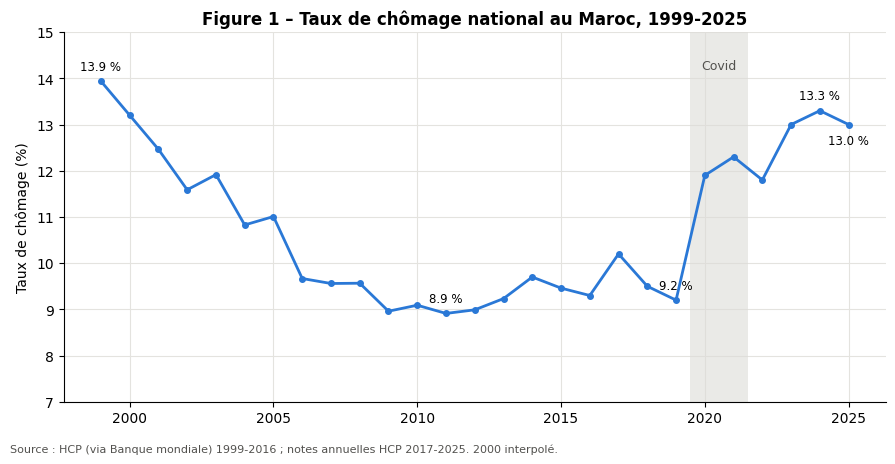

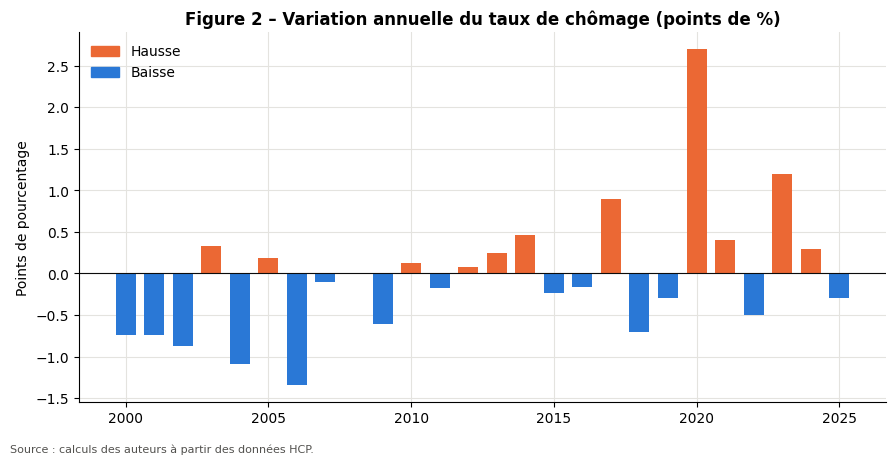

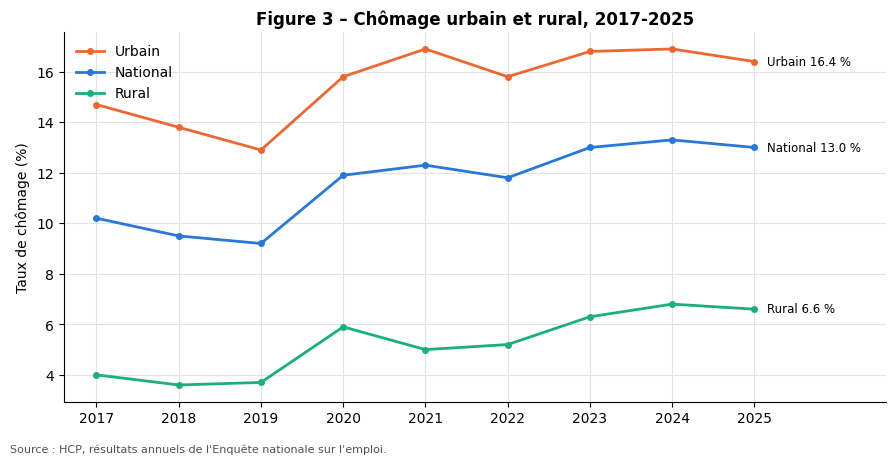

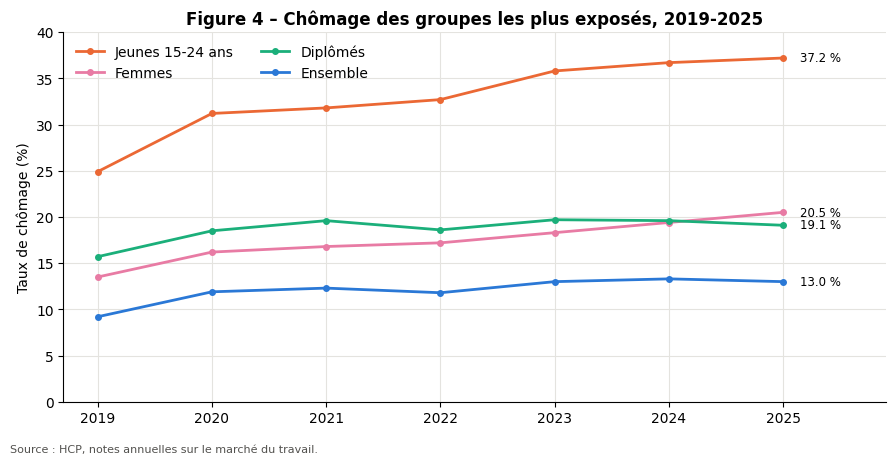

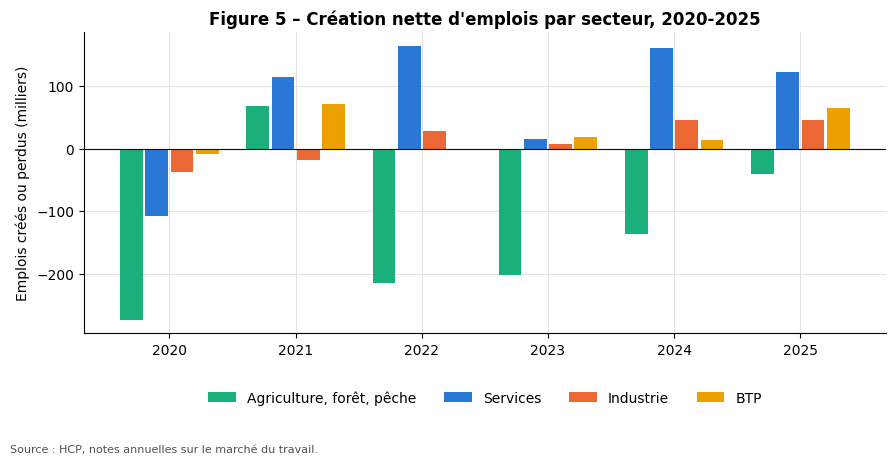

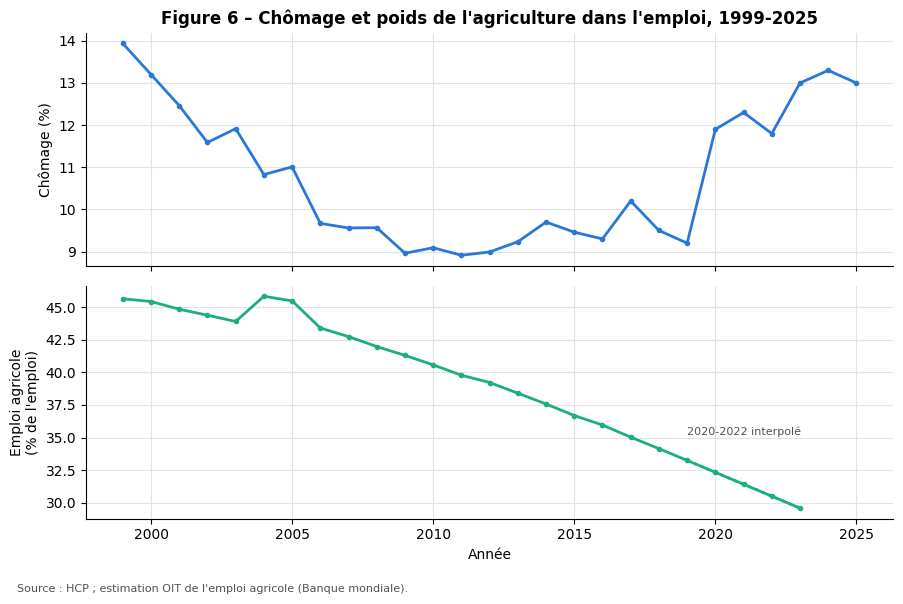

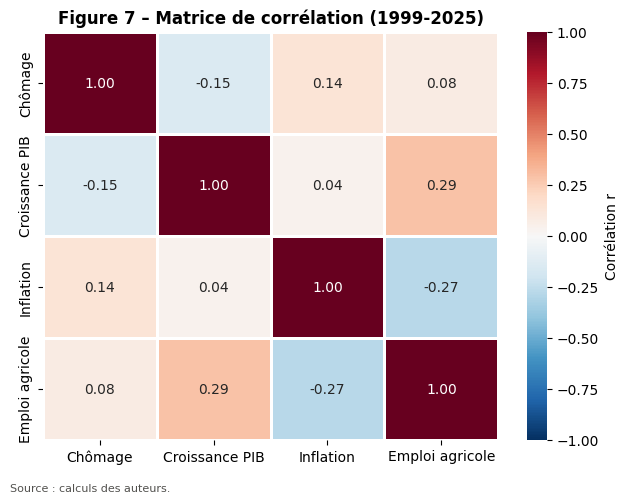

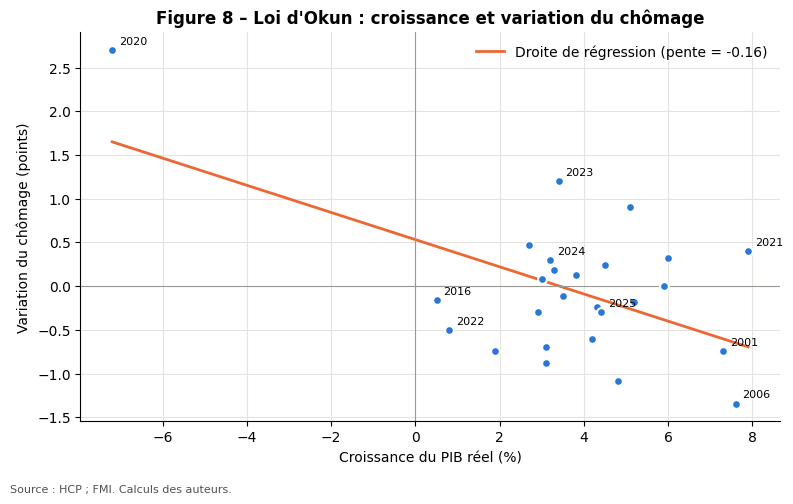

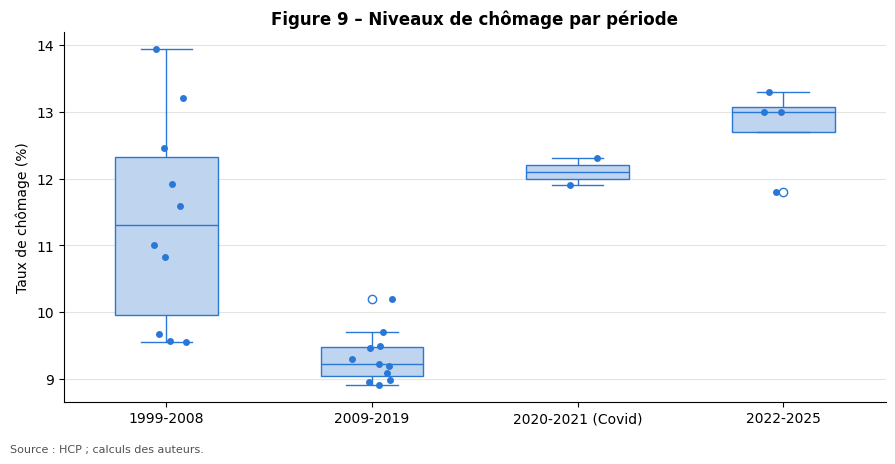

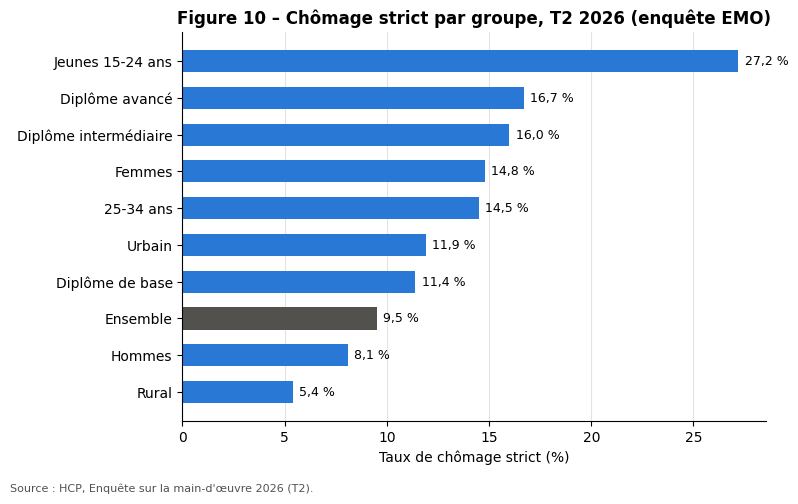

Terminé : 10 graphiques enregistrés dans le dossier figures/


In [4]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from matplotlib.patches import Patch

# ---------- Style commun ----------
BLEU, ORANGE, AQUA, JAUNE, MAGENTA, GRIS = "#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#52514e"
plt.rcParams.update({"figure.figsize": (9, 4.6), "axes.spines.top": False, "axes.spines.right": False,
                     "axes.grid": True, "grid.color": "#e4e3df", "axes.titleweight": "bold",
                     "axes.titlesize": 12, "lines.linewidth": 2, "axes.axisbelow": True})
os.makedirs("figures", exist_ok=True)

def src(fig, t):
    fig.text(0.01, 0.005, "Source : " + t, fontsize=8, color=GRIS)

def save(fig, nom):
    fig.tight_layout(rect=(0, 0.03, 1, 1))
    fig.savefig(f"figures/{nom}.png", dpi=200)   # enregistre l'image
    plt.show()                                   # affiche le graphique

# ---------- Préparation (nettoyage) ----------
df["chomage"] = df["chomage"].interpolate(limit=1)
df["emploi_agricole"] = df["emploi_agricole"].interpolate(limit=3, limit_area="inside")
df["variation_chomage"] = df["chomage"].diff()
df["periode"] = pd.cut(df.annee, [1998, 2008, 2019, 2021, 2025],
                       labels=["1999-2008", "2009-2019", "2020-2021 (Covid)", "2022-2025"])

# ---------- Figure 1 : évolution du chômage ----------
fig, ax = plt.subplots()
ax.axvspan(2019.5, 2021.5, color="#dddcd8", alpha=.6, lw=0)
ax.text(2020.5, 14.2, "Covid", ha="center", fontsize=9, color=GRIS)
ax.plot(df.annee, df.chomage, color=BLEU, marker="o", ms=4)
for a in [1999, 2011, 2019, 2024, 2025]:
    v = df.loc[df.annee == a, "chomage"].item()
    ax.annotate(f"{v:.1f} %", (a, v), textcoords="offset points",
                xytext=(0, -14) if a == 2025 else (0, 8), ha="center", fontsize=8.5)
ax.set_title("Figure 1 – Taux de chômage national au Maroc, 1999-2025")
ax.set_ylabel("Taux de chômage (%)"); ax.set_ylim(7, 15)
src(fig, "HCP (via Banque mondiale) 1999-2016 ; notes annuelles HCP 2017-2025. 2000 interpolé.")
save(fig, "G1_evolution")

# ---------- Figure 2 : variation annuelle ----------
fig, ax = plt.subplots()
d = df.dropna(subset=["variation_chomage"])
ax.bar(d.annee, d.variation_chomage, color=[ORANGE if v > 0 else BLEU for v in d.variation_chomage], width=.7)
ax.axhline(0, color="#0b0b0b", lw=.8)
ax.set_title("Figure 2 – Variation annuelle du taux de chômage (points de %)")
ax.set_ylabel("Points de pourcentage")
ax.legend(handles=[Patch(color=ORANGE, label="Hausse"), Patch(color=BLEU, label="Baisse")],
          frameon=False, loc="upper left")
src(fig, "calculs des auteurs à partir des données HCP.")
save(fig, "G2_variation")

# ---------- Figure 3 : urbain et rural ----------
fig, ax = plt.subplots()
for c, l, col in [("urbain", "Urbain", ORANGE), ("national", "National", BLEU), ("rural", "Rural", AQUA)]:
    ax.plot(hcp.annee, hcp[c], color=col, marker="o", ms=4, label=l)
    ax.text(2025.15, hcp[c].iloc[-1], f"{l} {hcp[c].iloc[-1]:.1f} %", va="center", fontsize=8.5)
ax.set_xlim(2016.6, 2026.6); ax.set_xticks(range(2017, 2026))
ax.set_title("Figure 3 – Chômage urbain et rural, 2017-2025")
ax.set_ylabel("Taux de chômage (%)"); ax.legend(frameon=False, loc="upper left")
src(fig, "HCP, résultats annuels de l'Enquête nationale sur l'emploi.")
save(fig, "G3_urbain_rural")

# ---------- Figure 4 : groupes les plus exposés ----------
h = hcp.dropna(subset=["jeunes_15_24"])
fig, ax = plt.subplots()
for c, l, col in [("jeunes_15_24", "Jeunes 15-24 ans", ORANGE), ("femmes", "Femmes", MAGENTA),
                  ("diplomes", "Diplômés", AQUA), ("national", "Ensemble", BLEU)]:
    ax.plot(h.annee, h[c], color=col, marker="o", ms=4, label=l)
    ax.text(2025.15, h[c].iloc[-1], f"{h[c].iloc[-1]:.1f} %", va="center", fontsize=8.5)
ax.set_xlim(2018.7, 2025.9); ax.set_ylim(0, 40)
ax.set_title("Figure 4 – Chômage des groupes les plus exposés, 2019-2025")
ax.set_ylabel("Taux de chômage (%)"); ax.legend(frameon=False, loc="upper left", ncol=2)
src(fig, "HCP, notes annuelles sur le marché du travail.")
save(fig, "G4_groupes")

# ---------- Figure 5 : emplois par secteur ----------
e = hcp.dropna(subset=["emplois_agriculture_milliers"])
x = np.arange(len(e)); w = .2
fig, ax = plt.subplots()
for i, (c, l, col) in enumerate([("emplois_agriculture_milliers", "Agriculture, forêt, pêche", AQUA),
                                 ("emplois_services_milliers", "Services", BLEU),
                                 ("emplois_industrie_milliers", "Industrie", ORANGE),
                                 ("emplois_btp_milliers", "BTP", JAUNE)]):
    ax.bar(x + (i - 1.5) * w, e[c], w * .9, color=col, label=l)
ax.axhline(0, color="#0b0b0b", lw=.8)
ax.set_xticks(x, e.annee.astype(int)); ax.set_ylabel("Emplois créés ou perdus (milliers)")
ax.set_title("Figure 5 – Création nette d'emplois par secteur, 2020-2025")
ax.legend(frameon=False, ncol=4, loc="lower center", bbox_to_anchor=(.5, -.28))
src(fig, "HCP, notes annuelles sur le marché du travail.")
save(fig, "G5_secteurs")

# ---------- Figure 6 : chômage et emploi agricole ----------
fig, (a1, a2) = plt.subplots(2, 1, sharex=True, figsize=(9, 6))
a1.plot(df.annee, df.chomage, color=BLEU, marker="o", ms=3)
a1.set_ylabel("Chômage (%)")
a1.set_title("Figure 6 – Chômage et poids de l'agriculture dans l'emploi, 1999-2025")
m = df.emploi_agricole.notna()
a2.plot(df.annee[m], df.emploi_agricole[m], color=AQUA, marker="o", ms=3)
a2.plot([2019, 2023], [33.25, 29.59], color=AQUA, ls=":", lw=2)
a2.set_ylabel("Emploi agricole\n(% de l'emploi)"); a2.set_xlabel("Année")
a2.text(2021, 35.2, "2020-2022 interpolé", fontsize=8, color=GRIS, ha="center")
src(fig, "HCP ; estimation OIT de l'emploi agricole (Banque mondiale).")
save(fig, "G6_agriculture")

# ---------- Figure 7 : matrice de corrélation ----------
cols = ["chomage", "croissance_pib", "inflation", "emploi_agricole"]
noms = ["Chômage", "Croissance PIB", "Inflation", "Emploi agricole"]
cor = df[cols].corr(); cor.index = noms; cor.columns = noms
fig, ax = plt.subplots(figsize=(6.4, 5))
sns.heatmap(cor, annot=True, fmt=".2f", cmap="RdBu_r", vmin=-1, vmax=1, ax=ax,
            cbar_kws={"label": "Corrélation r"}, linewidths=2, linecolor="white")
ax.set_title("Figure 7 – Matrice de corrélation (1999-2025)")
src(fig, "calculs des auteurs.")
save(fig, "G7_correlations")

# ---------- Figure 8 : loi d'Okun ----------
d = df.dropna(subset=["variation_chomage", "croissance_pib"])
res = stats.linregress(d.croissance_pib, d.variation_chomage)
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(d.croissance_pib, d.variation_chomage, color=BLEU, s=40, edgecolor="white", lw=1.5, zorder=3)
xs = np.linspace(d.croissance_pib.min(), d.croissance_pib.max(), 50)
ax.plot(xs, res.intercept + res.slope * xs, color=ORANGE, lw=2,
        label=f"Droite de régression (pente = {res.slope:.2f})")
for _, r in d.iterrows():
    if r.annee in (2001, 2006, 2016, 2020, 2021, 2022, 2023, 2024, 2025):
        ax.annotate(int(r.annee), (r.croissance_pib, r.variation_chomage),
                    xytext=(5, 4), textcoords="offset points", fontsize=8)
ax.axhline(0, color="#9a9993", lw=.8); ax.axvline(0, color="#9a9993", lw=.8)
ax.set_xlabel("Croissance du PIB réel (%)"); ax.set_ylabel("Variation du chômage (points)")
ax.set_title("Figure 8 – Loi d'Okun : croissance et variation du chômage")
ax.legend(frameon=False, loc="upper right")
src(fig, "HCP ; FMI. Calculs des auteurs.")
save(fig, "G8_okun")

# ---------- Figure 9 : niveaux par période ----------
fig, ax = plt.subplots()
sns.boxplot(data=df, x="periode", y="chomage", color="#b7d3f6", width=.5, ax=ax, linecolor=BLEU)
sns.stripplot(data=df, x="periode", y="chomage", color=BLEU, size=5, ax=ax)
ax.set_xlabel(""); ax.set_ylabel("Taux de chômage (%)")
ax.set_title("Figure 9 – Niveaux de chômage par période")
src(fig, "HCP ; calculs des auteurs.")
save(fig, "G9_periodes")

# ---------- Figure 10 : chômage strict par groupe (T2 2026) ----------
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(emo.groupe, emo.taux, color=[BLEU if g != "Ensemble" else GRIS for g in emo.groupe], height=.6)
for i, v in enumerate(emo.taux):
    ax.text(v + .3, i, f"{v:.1f} %".replace(".", ","), va="center", fontsize=9)
ax.set_xlabel("Taux de chômage strict (%)")
ax.set_title("Figure 10 – Chômage strict par groupe, T2 2026 (enquête EMO)")
ax.grid(axis="y", visible=False)
src(fig, "HCP, Enquête sur la main-d'œuvre 2026 (T2).")
save(fig, "G10_emo2026")

print("Terminé : 10 graphiques enregistrés dans le dossier figures/")